In [62]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download = True, train = True) #imports e download do fmnist

In [63]:
tr_images = fmnist.data
tr_targets = fmnist.targets #dados do fmnist

In [64]:
val_fmnist = datasets.FashionMNIST(data_folder, download = True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

In [83]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
device = "cuda" if torch.cuda.is_available() else "cpu" #se vai rodar na gpu ou cpu
from torchvision import datasets #imports

In [86]:
class FMNISTDataset(Dataset): #classe pro dataset
    def __init__(self, x, y): 
        x = x.float() #converte pra float
        x = x.view(-1, 28*28) / 255 #diminui a imagem
        self.x, self.y = x, y 
    def __getitem__(self, idx):  #funcao q pega a imagem
        x, y = self.x[idx], self.y[idx] 
        return x.to(device), y.to(device)
    def __len__(self): #funcao q retorna a qntd de imagens
        return len(self.x)

In [87]:
from torch.optim import SGD
def get_model(): #cria o modelo
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), #camada q recebe a imagem
        nn.ReLU(), #ativacao
        nn.Linear(1000, 1000),
        nn.ReLU(), #ativacao
        nn.Linear(1000, 10) #pegas os 1000 q a entrada faz e colo em 10 de saida
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()  #funcao de perda
    optimizer = Adam(model.parameters(), lr=1e-3) #otimizador
    return model, loss_fn, optimizer

In [88]:
def train_batch(x, y, model, opt, loss_fn):
    model.train() #treina o modelo
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) #ve o erro
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad() #atualiza os pesos
    return batch_loss.item()
def accuracy(x, y, model):
    model.eval()  #avaliacao
    with torch.no_grad():
        prediction = model(x) #faz as previsoes
    max_values, argmaxes = prediction.max(-1) #pega a maior prob do modelo
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist() #coloca tudo em lista

In [89]:
@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x) #faz as previsoes
    val_loss = loss_fn(prediction, y) #pega o erro
    return val_loss.item()

In [90]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets) #pega os dados
    trn_dl = DataLoader(train, batch_size = 32, shuffle = True) #embaralha
    val = FMNISTDataset(val_images, val_targets) #dado pra validar
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle = False) #nao embaralha
    return trn_dl, val_dl

In [91]:
trn_dl, val_dl = get_data() #pega os dados
model, loss_fn, optimizer = get_model() #coloca em modelo

In [92]:
import numpy as np
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []#listas pra guardar, perda e acuracia
for epoch in range(5): #epochs
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)): #treina a rede
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss) #guarda o erro
    train_epoch_loss = np.array(train_epoch_losses).mean() #guarda a media do erro da epoca
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies) #guarda a media de acuracia de treinp
    for ix, batch in enumerate(iter(val_dl)): #e testa ela
        x, y = batch
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) 
        
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy) #guarda todos os dados finais

0
1
2
3
4


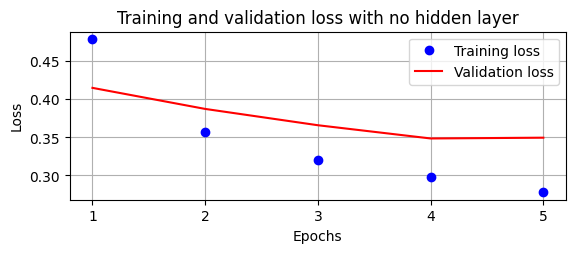

/tmp/ipykernel_165592/3064575515.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


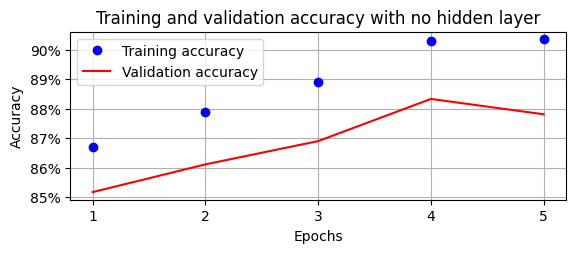

In [94]:
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline #imports 

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1)) 
plt.title('Training and validation loss with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show() #um grafico que mostr ao erro de erro e teste

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show() #grafico que mostra a acuracia 